# Visualization Tools & Best Practices — Unit IV

## Day 1: Chart Selection Guidelines

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

iris = pd.read_csv("data/iris.csv")
sales = pd.read_csv("data/sales_timeseries_reviews.csv", parse_dates=["Date"])

print(iris.shape, sales.shape)
iris.head()

(150, 5) (731, 4)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Chart Selection Guidelines:**

| Question you're asking | Best chart | Why |
|---|---|---|
| How is one numeric variable distributed? | Histogram / Density plot | Shows shape, spread, skew |
| How does a value change over time? | Line chart | Preserves order, shows trend |
| How do categories compare in size/count? | Bar chart | Easy magnitude comparison |
| What's the share of a whole? | Pie chart (only for few categories) | Shows proportion |
| Is there a relationship between two numeric variables? | Scatter plot | Shows direction/strength of association |
| How does a numeric variable compare across groups? | Box plot / Violin plot | Shows spread + outliers per group |
| How do many variables relate at once? | Heatmap / Pair plot | Compresses many relationships into one view |

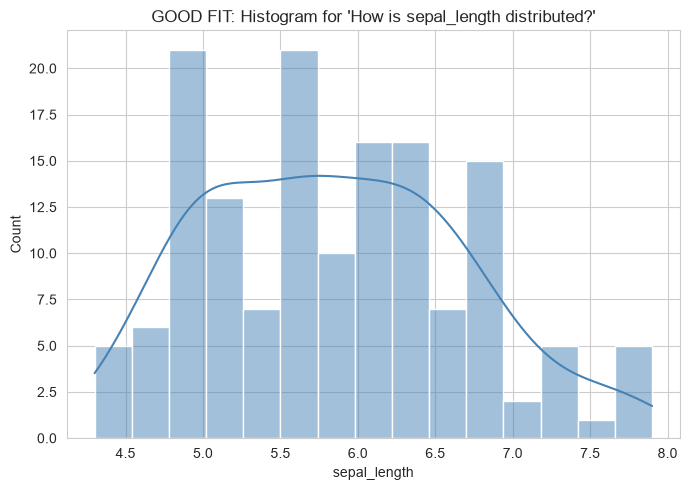

In [2]:
plt.figure(figsize=(7, 5))
sns.histplot(iris["sepal_length"], bins=15, kde=True, color="steelblue")
plt.title("GOOD FIT: Histogram for 'How is sepal_length distributed?'")
plt.tight_layout()
plt.savefig("outputs/day1_good_histogram.png", dpi=120)
plt.show()

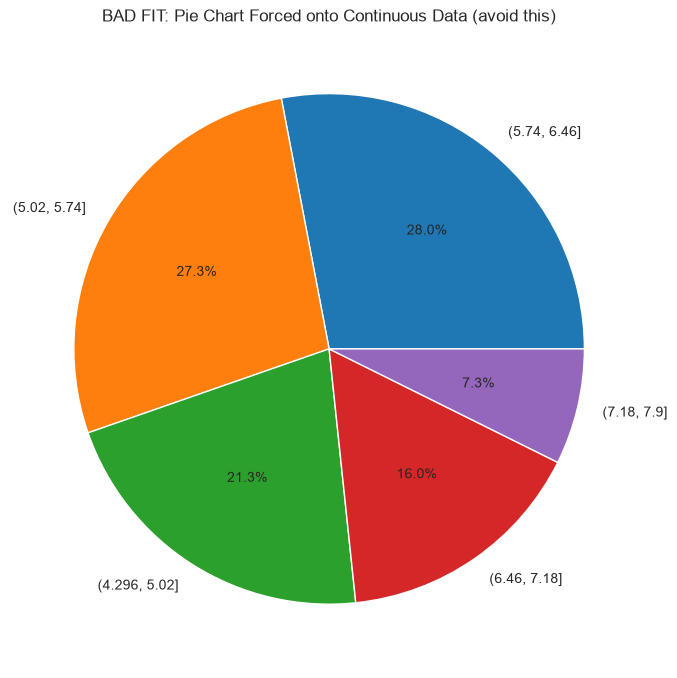

In [3]:
# BAD FIT demonstration: pie charts don't work for continuous numeric data
bins = pd.cut(iris["sepal_length"], bins=5)
bin_counts = bins.value_counts()

plt.figure(figsize=(7, 7))
plt.pie(bin_counts.values, labels=[str(i) for i in bin_counts.index], autopct="%1.1f%%")
plt.title("BAD FIT: Pie Chart Forced onto Continuous Data (avoid this)")
plt.tight_layout()
plt.savefig("outputs/day1_bad_piechart.png", dpi=120)
plt.show()

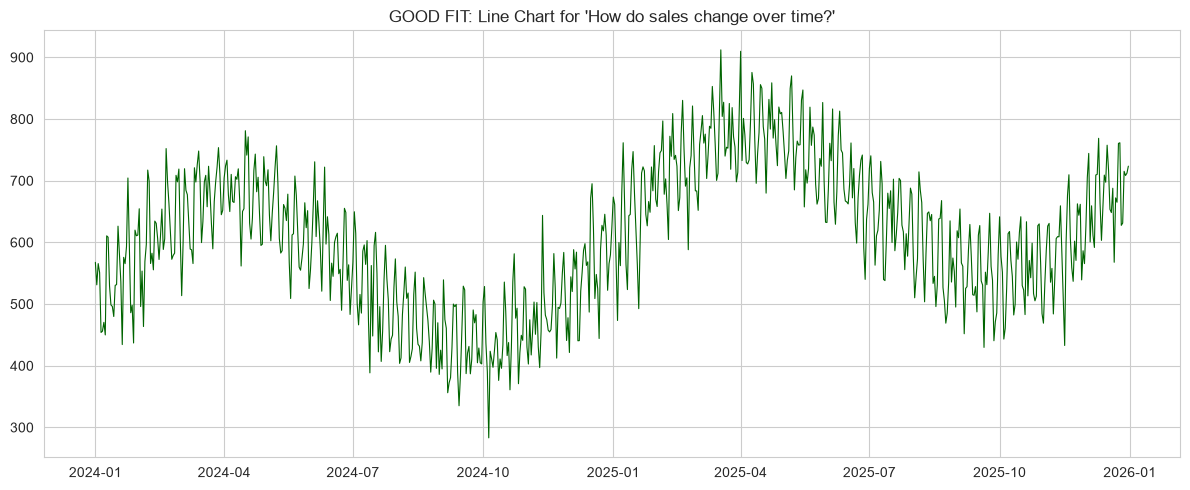

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(sales["Date"], sales["Daily_Sales"], color="darkgreen", linewidth=0.8)
plt.title("GOOD FIT: Line Chart for 'How do sales change over time?'")
plt.tight_layout()
plt.savefig("outputs/day1_good_linechart.png", dpi=120)
plt.show()

C:\Users\D.NIKITHA\AppData\Local\Temp\ipykernel_23216\2510308371.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_avg.index, y=cat_avg.values, palette="viridis", ax=axes[0])


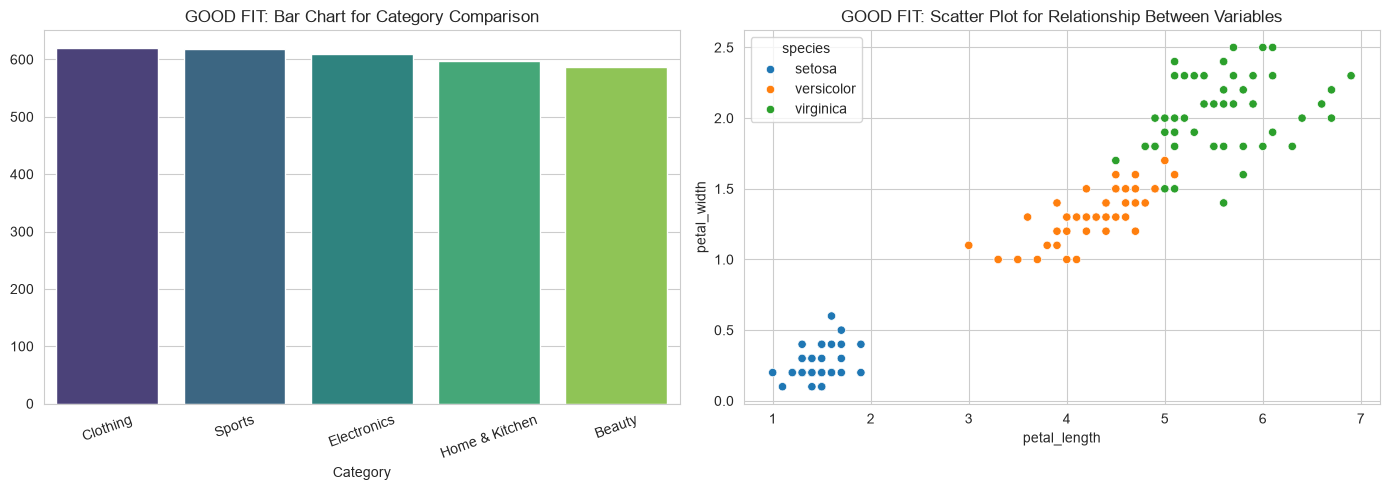

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_avg = sales.groupby("Category")["Daily_Sales"].mean().sort_values(ascending=False)
sns.barplot(x=cat_avg.index, y=cat_avg.values, palette="viridis", ax=axes[0])
axes[0].set_title("GOOD FIT: Bar Chart for Category Comparison")
axes[0].tick_params(axis='x', rotation=20)

sns.scatterplot(data=iris, x="petal_length", y="petal_width", hue="species", ax=axes[1])
axes[1].set_title("GOOD FIT: Scatter Plot for Relationship Between Variables")

plt.tight_layout()
plt.savefig("outputs/day1_bar_vs_scatter.png", dpi=120)
plt.show()

**Observation:** The core principle of chart selection is matching the
chart's structure to the *question being asked*, not just what data happens
to be available. A histogram reveals distribution shape that a pie chart
completely hides once continuous data is artificially binned into
categories. Line charts preserve the order essential to time series, while
bar charts (unordered categories) and scatter plots (relationships between
two numeric variables) each serve a distinct purpose. Choosing the wrong
chart type doesn't just look worse — it can actively mislead the viewer
about what the data shows.